In [1]:
!pip install ultralytics roboflow -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 57.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.2/249.2 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 66.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 101.7 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
import os

BASE_FOLDER = "/content/drive/MyDrive/PoultryVision"
os.makedirs(BASE_FOLDER, exist_ok=True)

print(f"Folder creado: {BASE_FOLDER}")

Folder creado: /content/drive/MyDrive/PoultryVision


In [4]:
from ultralytics import YOLO
from roboflow import Roboflow

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [5]:
import torch

In [ ]:
print("GPU:", torch.cuda.get_device_name(0))
print("VRAM (GB):", torch.cuda.get_device_properties(0).total_memory / 1e9)

GPU: Tesla T4
VRAM (GB): 15.637086208


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="msBZMg6r6SYDEn42M4RX")
project = rf.workspace("myworkspace-rde28").project("chickens-kshiz-rvhan")
version = project.version(1)
dataset1 = version.download("yolov11")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Chickens-1 in yolov11:: 100%|██████████| 4216/4216 [00:00<00:00, 6113.03it/s]


In [ ]:
!ls {dataset1.location}

data.yaml  README.roboflow.txt	test  train  valid


In [ ]:
rf2 = Roboflow(api_key="msBZMg6r6SYDEn42M4RX")
project = rf2.workspace("prince-songkla-university").project("chicken-detection-r42oo")
version = project.version(1)
dataset2 = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to chicken-detection-1 in yolov11:: 100%|██████████| 5856/5856 [00:01<00:00, 4483.35it/s]


In [ ]:
CHICKEN_DATASET_PATH = "/content/Chickens-1"

In [ ]:
PRINCE_SONGKLA_DATASET_PATH = "/content/chicken-detection-1"

In [ ]:
OUTPUT = "/content/chicken_master_dataset"

In [ ]:
splits = ["train", "valid", "test"]

In [ ]:
import os
import shutil
from pathlib import Path

In [ ]:
for split in splits:

    os.makedirs(
        os.path.join(OUTPUT, split, "images"),
        exist_ok=True
    )

    os.makedirs(
        os.path.join(OUTPUT, split, "labels"),
        exist_ok=True
    )

    # Dataset A
    img_src = os.path.join(CHICKEN_DATASET_PATH, split, "images")
    lbl_src = os.path.join(CHICKEN_DATASET_PATH, split, "labels")

    if os.path.exists(img_src):

        for file in os.listdir(img_src):

            src = os.path.join(img_src, file)
            dst = os.path.join(
                OUTPUT,
                split,
                "images",
                f"A_{file}"
            )

            shutil.copy2(src, dst)

    if os.path.exists(lbl_src):

        for file in os.listdir(lbl_src):

            src = os.path.join(lbl_src, file)
            dst = os.path.join(
                OUTPUT,
                split,
                "labels",
                f"A_{file}"
            )

            shutil.copy2(src, dst)

    # Dataset B
    img_src = os.path.join(PRINCE_SONGKLA_DATASET_PATH, split, "images")
    lbl_src = os.path.join(PRINCE_SONGKLA_DATASET_PATH, split, "labels")

    if os.path.exists(img_src):

        for file in os.listdir(img_src):

            src = os.path.join(img_src, file)
            dst = os.path.join(
                OUTPUT,
                split,
                "images",
                f"B_{file}"
            )

            shutil.copy2(src, dst)

    if os.path.exists(lbl_src):

        for file in os.listdir(lbl_src):

            src = os.path.join(lbl_src, file)
            dst = os.path.join(
                OUTPUT,
                split,
                "labels",
                f"B_{file}"
            )

            shutil.copy2(src, dst)


In [ ]:
yaml_content = """
path: /content/chicken_master_dataset

train: train/images
val: valid/images
test: test/images

nc: 1

names:
  0: Chicken
"""

with open("/content/chicken_master_dataset/data.yaml", "w") as f:
    f.write(yaml_content)

In [ ]:
from collections import Counter
from pathlib import Path

In [ ]:
labels_dir = Path(
    "/content/chicken_master_dataset/train/labels"
)

In [ ]:
counter = Counter()


In [ ]:
for txt in labels_dir.glob("*.txt"):

    with open(txt) as f:

        for line in f:

            cls = int(line.split()[0])
            counter[cls] += 1

print(counter)

Counter({0: 15604})


In [6]:
from ultralytics import YOLO

In [ ]:
model = YOLO("yolo11s.pt")

In [ ]:
model.train(
    data="/content/chicken_master_dataset/data.yaml",
    epochs=100,
    imgsz=640,
    batch=32,
    device=0,
    workers=4,
    patience=10,
    project=BASE_FOLDER ,
    name="chicken_v1",
    verbose=True,
)

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/chicken_master_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=chicken_v1-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tr

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x791e081a8800>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [ ]:
metrics = model.val()
print(metrics)

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2162.4±1017.1 MB/s, size: 59.3 KB)
val: Scanning /content/chicken_master_dataset/valid/labels.cache... 682 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 682/682 260.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 43/43 3.4it/s 12.5s
                   all        682       2139      0.904      0.885      0.925      0.708
Speed: 1.7ms preprocess, 10.8ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to /content/runs/detect/val-2
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x791e081bddf0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: 

In [ ]:
metrics_test = model.val(split="test")
print(metrics_test)

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 37.2±9.2 MB/s, size: 76.1 KB)
val: Scanning /content/chicken_master_dataset/test/labels... 357 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 357/357 468.7it/s 0.8s
val: New cache created: /content/chicken_master_dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 23/23 2.7it/s 8.6s
                   all        357       1205      0.945      0.846      0.925      0.702
Speed: 3.3ms preprocess, 12.1ms inference, 0.0ms loss, 1.5ms postprocess per image
Results saved to /content/runs/detect/val-3
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x791e9cbd6480>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precis

In [ ]:
len(results[0].boxes)

4

In [10]:
import os
import glob
import json
import torch

In [11]:
from ultralytics import YOLO
from PIL import Image
from google.colab.patches import cv2_imshow

In [12]:
model_path = f"{BASE_FOLDER}/chicken_v1/weights/best.pt"
#model_path ="/content/drive/MyDrive/PoultryVision/chicken_PIO_V3/weights/best.pt"



In [13]:
model = YOLO(model_path)

In [14]:
test_image_dir = '/content/test_imgs/'
image_extensions = ['*.jpg', '*.jpeg', '*.png']

In [15]:
image_files = []

for ext in image_extensions:
    image_files.extend(glob.glob(os.path.join(test_image_dir, ext)))

In [16]:
all_results_data = []

--- Starting Inference on 3 images ---

image 1/1 /content/test_imgs/chickens_1.png: 1024x1280 121 Chickens, 114.0ms
Speed: 12.3ms preprocess, 114.0ms inference, 54.6ms postprocess per image at shape (1, 3, 1024, 1280)

File: chickens_1.png | Detected Objects: 121


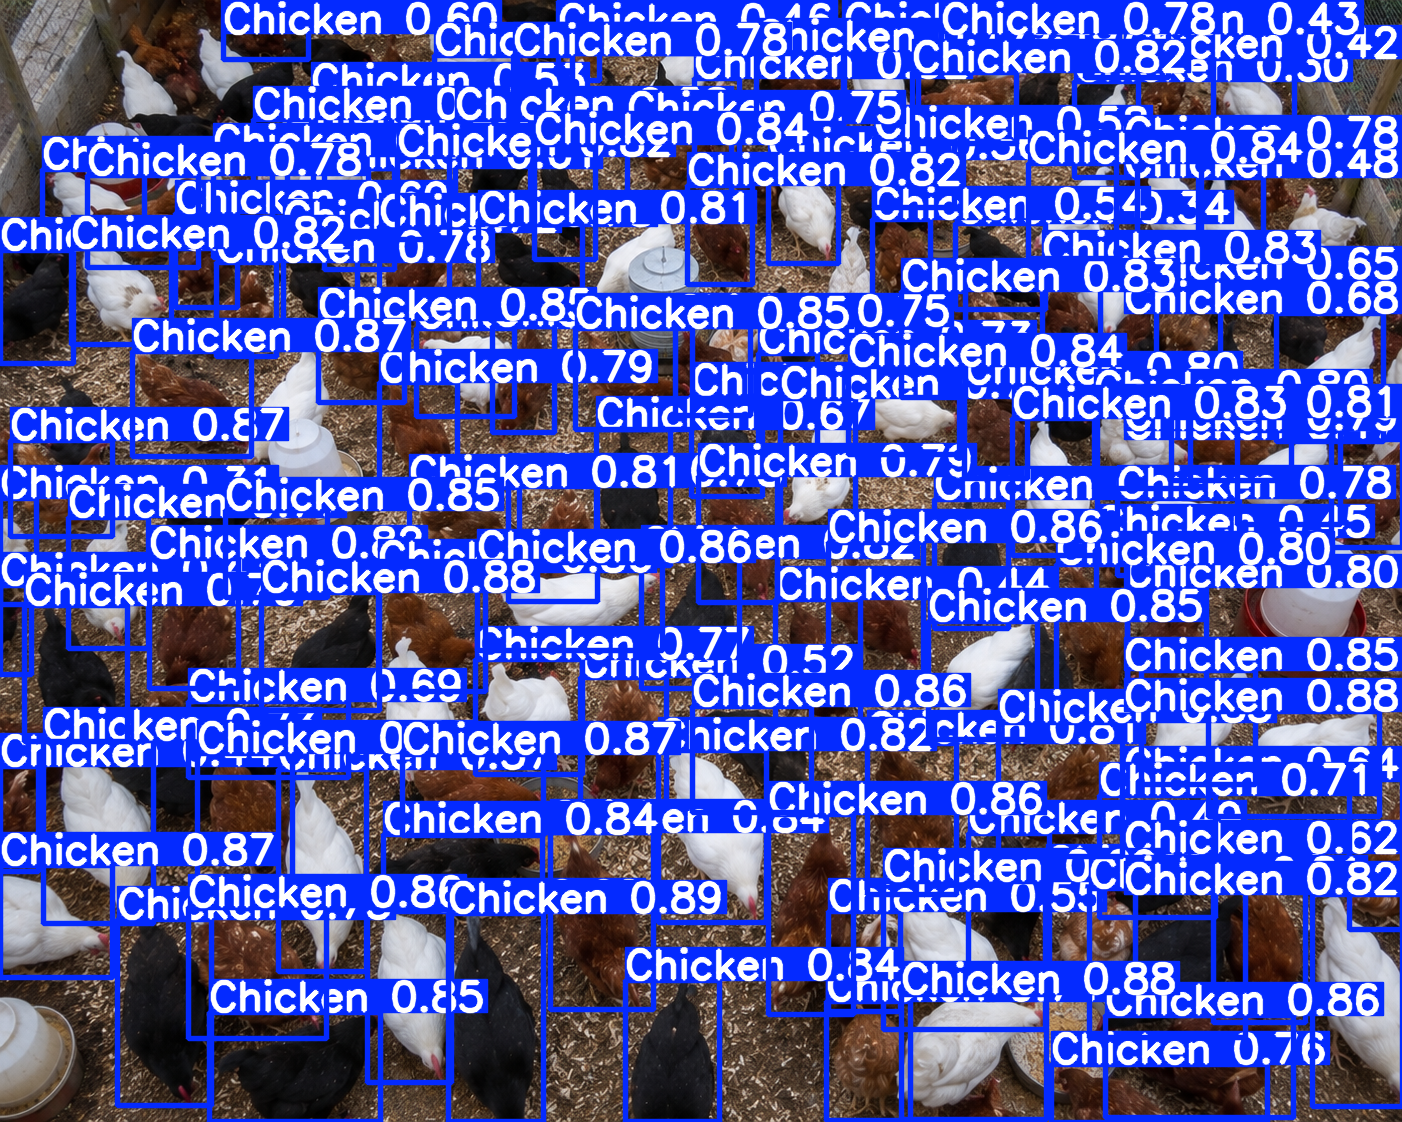


image 1/1 /content/test_imgs/hens_barn.png: 1056x1280 73 Chickens, 102.6ms
Speed: 15.9ms preprocess, 102.6ms inference, 2.0ms postprocess per image at shape (1, 3, 1056, 1280)

File: hens_barn.png | Detected Objects: 73


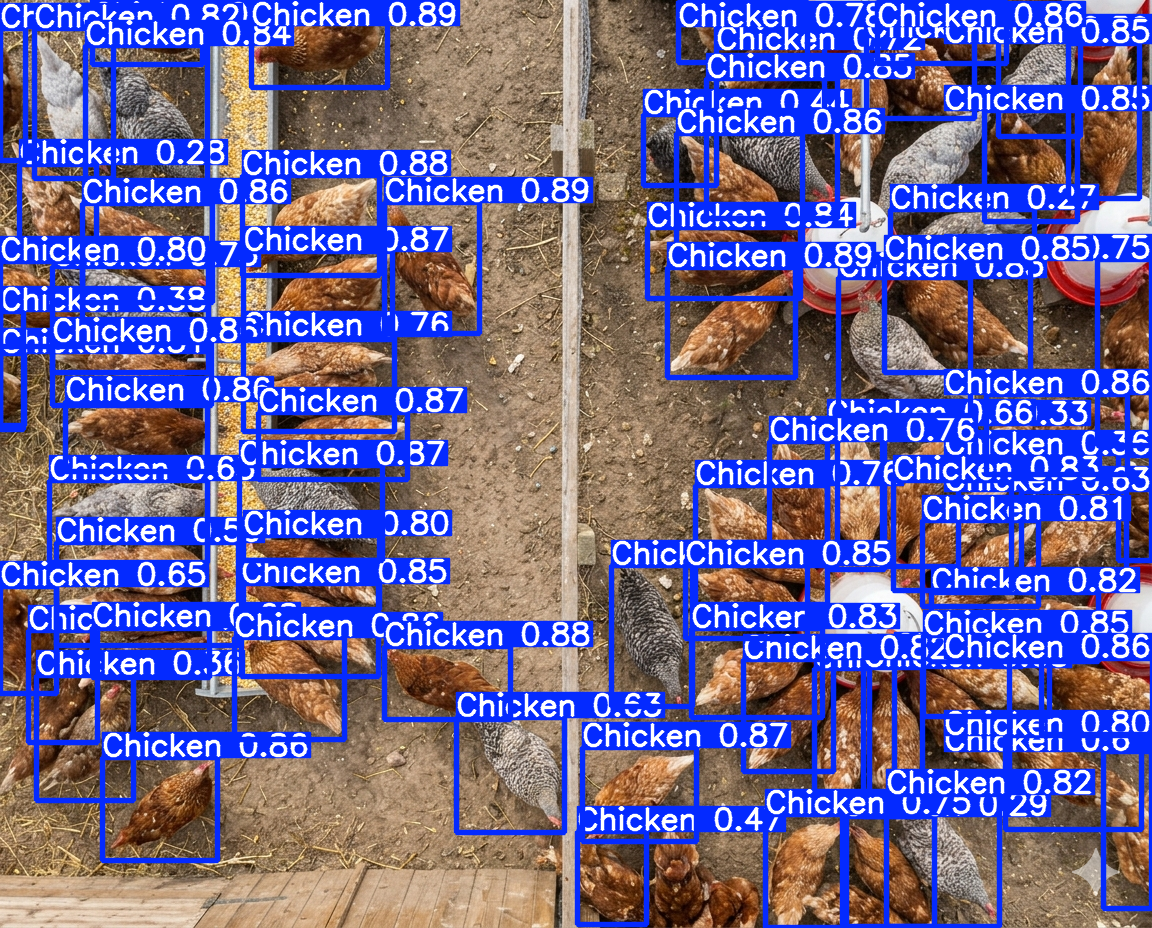


image 1/1 /content/test_imgs/drifting_hens.png: 704x1280 39 Chickens, 88.3ms
Speed: 8.4ms preprocess, 88.3ms inference, 1.9ms postprocess per image at shape (1, 3, 704, 1280)

File: drifting_hens.png | Detected Objects: 39


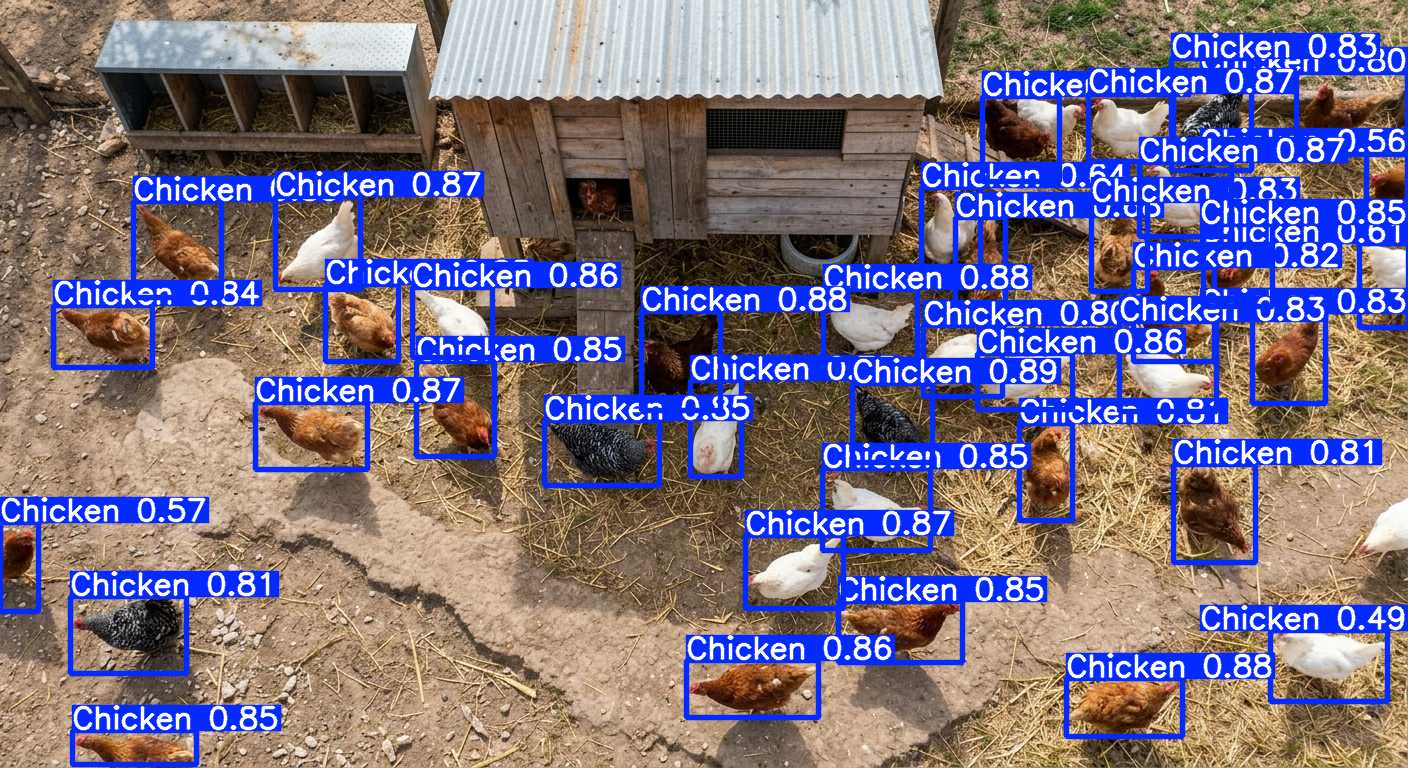


--- Final Inference JSON Report ---


In [17]:
print(f"--- Starting Inference on {len(image_files)} images ---")
for img_path in image_files:
    # Run inference
    # conf=0.25 is standard, adjust if you want more/fewer detections
    results = model.predict(source=img_path, conf=0.25, iou=0.6, imgsz=1280 )

    result = results[0]
    num_objects = len(result.boxes)
    filename = os.path.basename(img_path)

    # Display Image with Bounding Boxes
    print(f"\nFile: {filename} | Detected Objects: {num_objects}")
    annotated_img = result.plot() # Returns a numpy array (BGR)

    # Convert BGR to RGB for correct display
    display_img = Image.fromarray(annotated_img[..., ::-1])
    display(display_img)

    # Prepare JSON data for this image
    image_json = {
        "filename": filename,
        "object_count": num_objects,
        "detections": []
    }

    # Extract box coordinates and confidence
    for box in result.boxes:
        image_json["detections"].append({
            "class_id": int(box.cls[0]),
            "label": "Object",
            "confidence": float(box.conf[0]),
            "bbox_xyxy": box.xyxy[0].tolist() # [xmin, ymin, xmax, ymax]
        })

    all_results_data.append(image_json)

# 4. Print and Save JSON Output
final_json = json.dumps(all_results_data, indent=4)
print("\n--- Final Inference JSON Report ---")
#print(final_json)

In [ ]:
# Good

In [ ]:
print(f"--- Starting Export to ONNX (Opset 18) ---")
success = model.export(
    format='onnx',
    opset=18,
    simplify=True,
    imgsz=640,
)

--- Starting Export to ONNX (Opset 18) ---
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/content/drive/MyDrive/PoultryVision/chicken_v1-2/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (18.3 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 320ms
Prepared 4 packages in 1.47s
Installed 4 packages in 250ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime==1.26.0
 + onnxslim==0.1.94

requirements: AutoUpdate success ✅ 2.6s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 18...
ONNX: slimming with onnxslim 0.1.